# Modelo 3 — Clustering / Segmentacion de Clientes

**Dataset:** Instacart Market Basket Analysis (Kaggle)  
**Objetivo:** Agrupar usuarios en segmentos de comportamiento ("personas") para entender el negocio y habilitar estrategias personalizadas por segmento.

**Pregunta de negocio:** Que perfiles de comprador existen?

**Decisiones de diseno:**
- Poblacion: usuarios con >=5 pedidos en el historial prior
- Features: set completo — frecuencia, recencia/cadencia, volumen, lealtad, mix de departamentos, temporal
- Algoritmos: **K-Means** (principal) + **jerarquico Ward** sobre muestra (validacion de k)
- Notebook autonoma desde raw CSVs

**Pipeline de preprocesamiento:**
1. **Log-transform** de features sesgadas (n_orders, total_items, unique_products, mean_basket_size)
2. **PCA agresivo sobre departamentos:** 21 proporciones -> **5 componentes fijos** (las proporciones composicionales no se separan bien en alta dimensionalidad)
3. **Eliminar redundancia temporal:** las 4 franjas horarias suman 1, asi que se elimina una (evita colinealidad perfecta)
4. **StandardScaler global** sobre las ~16 features resultantes

**Metricas:** inercia (codo), silhouette, Davies-Bouldin, ARI (validacion jerarquico vs K-Means)

## 1. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)

DATA_RAW  = Path("../data/raw/instacart")
DATA_PROC = Path("../data/processed")
MODELS    = Path("../models")

DATA_PROC.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print("Setup completo.")

Setup completo.


## 2. Carga de Datos desde Raw

Leemos solo columnas necesarias con `usecols` y tipos reducidos (`int32`) para minimizar RAM.

In [2]:
print("Cargando orders.csv ...")
orders = pd.read_csv(
    DATA_RAW / "orders.csv",
    usecols=["order_id", "user_id", "order_number", "order_dow",
             "order_hour_of_day", "days_since_prior_order", "eval_set"],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
    },
)
orders_prior = orders[orders["eval_set"] == "prior"].drop(columns="eval_set")
del orders
print(f"  orders prior: {len(orders_prior):,} filas")

print("Cargando order_products__prior.csv ...")
prior = pd.read_csv(
    DATA_RAW / "order_products__prior.csv",
    usecols=["order_id", "product_id", "reordered"],
    dtype={"order_id": "int32", "product_id": "int32", "reordered": "int8"},
)
print(f"  prior interactions: {len(prior):,} filas")

print("Cargando products.csv y departments.csv ...")
products = pd.read_csv(
    DATA_RAW / "products.csv",
    usecols=["product_id", "department_id"],
    dtype={"product_id": "int32", "department_id": "int8"},
)
departments = pd.read_csv(DATA_RAW / "departments.csv", dtype={"department_id": "int8"})
prod_dept = products.merge(departments, on="department_id")[["product_id", "department"]]
del products, departments
print(f"  productos con departamento: {len(prod_dept):,}")
print("Carga completa.")

Cargando orders.csv ...
  orders prior: 3,214,874 filas
Cargando order_products__prior.csv ...
  prior interactions: 32,434,489 filas
Cargando products.csv y departments.csv ...
  productos con departamento: 49,688
Carga completa.


## 3. Definicion de Poblacion (>=5 Pedidos Prior)

Filtramos usuarios con al menos 5 pedidos en el historial prior. Garantiza senal estadistica suficiente para cadencia, lealtad y mix de categorias.

In [3]:
user_order_counts = orders_prior.groupby("user_id")["order_id"].nunique().rename("n_orders")

total_users  = user_order_counts.shape[0]
active_users = user_order_counts[user_order_counts >= 5].index

print(f"Usuarios totales (prior):       {total_users:>10,}")
print(f"Usuarios con >=5 pedidos:       {len(active_users):>10,}  ({100*len(active_users)/total_users:.1f}%)")
print(f"Usuarios excluidos (<5 pedidos): {total_users - len(active_users):>9,}  ({100*(total_users-len(active_users))/total_users:.1f}%)")

orders_active = orders_prior[orders_prior["user_id"].isin(active_users)].copy()
prior_active  = prior[prior["order_id"].isin(orders_active["order_id"])]
del orders_prior, prior

print(f"\nPedidos prior activos:       {len(orders_active):>10,}")
print(f"Interacciones prior activos: {len(prior_active):>10,}")

Usuarios totales (prior):          206,209
Usuarios con >=5 pedidos:          162,633  (78.9%)
Usuarios excluidos (<5 pedidos):    43,576  (21.1%)

Pedidos prior activos:        3,064,556
Interacciones prior activos: 30,992,966


## 4. Feature Engineering por Usuario

| Grupo | Features | Cant. |
|---|---|---|
| Frecuencia | `n_orders`, `total_items` | 2 |
| Recencia / cadencia | `mean_days_since_prior`, `std_days_since_prior` | 2 |
| Volumen | `mean_basket_size`, `unique_products` | 2 |
| Lealtad | `reorder_rate` | 1 |
| Mix categorias | proporcion por departamento | 21 |
| Temporal | 4 franjas + `share_weekend` | 5 |
| **Total crudo** | | **33** |

In [4]:
# --- Frecuencia ---
freq = orders_active.groupby("user_id")["order_id"].nunique().rename("n_orders")
prior_user = prior_active.merge(orders_active[["order_id", "user_id"]], on="order_id")
del prior_active
total_items = prior_user.groupby("user_id")["product_id"].count().rename("total_items")
print("Frecuencia OK")

Frecuencia OK


In [5]:
# --- Recencia / Cadencia ---
cadence = (
    orders_active
    .groupby("user_id")["days_since_prior_order"]
    .agg(mean_days_since_prior="mean", std_days_since_prior="std")
)
cadence["std_days_since_prior"] = cadence["std_days_since_prior"].fillna(0.0)
print("Cadencia OK")

Cadencia OK


In [6]:
# --- Volumen ---
basket_size = (
    prior_user.groupby(["user_id", "order_id"])["product_id"]
    .count()
    .groupby("user_id")
    .mean()
    .rename("mean_basket_size")
)
unique_products = prior_user.groupby("user_id")["product_id"].nunique().rename("unique_products")
print("Volumen OK")

Volumen OK


In [7]:
# --- Lealtad ---
loyalty = prior_user.groupby("user_id")["reordered"].mean().rename("reorder_rate")
print("Lealtad OK")

Lealtad OK


In [8]:
# --- Mix de Categorias (21 departamentos) ---
prior_dept = prior_user.merge(prod_dept, on="product_id", how="left")
del prior_user

dept_counts = (
    prior_dept.groupby(["user_id", "department"])["product_id"]
    .count()
    .reset_index(name="count")
)
del prior_dept

dept_pivot = dept_counts.pivot_table(
    index="user_id", columns="department", values="count", fill_value=0
)
dept_pivot.columns = [f"dept_{c.lower().replace(' ', '_').replace('-', '_')}" for c in dept_pivot.columns]
dept_pivot = dept_pivot.div(dept_pivot.sum(axis=1), axis=0)

print(f"Mix departamentos OK - {dept_pivot.shape[1]} features")

Mix departamentos OK - 21 features


### Features Temporales

Franjas horarias: Madrugada 0-5h, Manana 6-11h, Tarde 12-17h, Noche 18-23h.  
Fin de semana: `order_dow` 0 (sabado) y 1 (domingo).

In [9]:
# --- Temporal ---
def hora_a_franja(h):
    if h < 6:
        return "madrugada"
    elif h < 12:
        return "manana"
    elif h < 18:
        return "tarde"
    else:
        return "noche"

orders_active["franja"] = orders_active["order_hour_of_day"].map(hora_a_franja)

franja_counts = (
    orders_active.groupby(["user_id", "franja"])["order_id"]
    .count()
    .reset_index(name="cnt")
)
franja_pivot = franja_counts.pivot_table(
    index="user_id", columns="franja", values="cnt", fill_value=0
)
for f in ["madrugada", "manana", "tarde", "noche"]:
    if f not in franja_pivot.columns:
        franja_pivot[f] = 0
franja_pivot = franja_pivot[["madrugada", "manana", "tarde", "noche"]]
franja_pivot.columns = [f"share_{c}" for c in franja_pivot.columns]
franja_pivot = franja_pivot.div(franja_pivot.sum(axis=1), axis=0)

orders_active["is_weekend"] = orders_active["order_dow"].isin([0, 1]).astype("int8")
share_weekend = orders_active.groupby("user_id")["is_weekend"].mean().rename("share_weekend")

temporal = franja_pivot.join(share_weekend, how="left")
del orders_active, franja_counts, franja_pivot
print(f"Temporal OK - {temporal.shape[1]} features")

Temporal OK - 5 features


In [10]:
# --- Union de todas las features ---
user_features = (
    freq.to_frame()
    .join(total_items, how="left")
    .join(cadence, how="left")
    .join(basket_size, how="left")
    .join(unique_products, how="left")
    .join(loyalty, how="left")
    .join(dept_pivot, how="left")
    .join(temporal, how="left")
)
user_features = user_features.fillna(0)

print(f"Tabla de features crudas: {user_features.shape[0]:,} usuarios x {user_features.shape[1]} features")
print(f"NaN totales: {user_features.isna().sum().sum()}")

Tabla de features crudas: 162,633 usuarios x 33 features
NaN totales: 0


## 5. Preprocesamiento para Clustering

El preprocesamiento ataca tres problemas diagnosticados:

### Problema 1: Distribuciones sesgadas
`n_orders`, `total_items`, `unique_products`, `mean_basket_size` tienen skewness >1.2. `log1p(x)` simetriza las distribuciones para que K-Means (que asume clusters esfericos) funcione mejor.

### Problema 2: Maldicion de dimensionalidad (21 proporciones de departamento)
Las 21 proporciones de departamento son **composicionales** (suman 1) y ocupan un simplex en 21D. Esto diluye las distancias euclidianas. Reducimos agresivamente con **PCA a 5 componentes fijos** — esto captura los ejes principales de variacion en el mix de categorias sin inflar la dimensionalidad.

### Problema 3: Colinealidad perfecta en temporales
Las 4 franjas (madrugada + manana + tarde + noche) suman exactamente 1. Esto introduce una dependencia lineal perfecta que confunde al scaler y al algoritmo. Eliminamos `share_tarde` (la mas frecuente/menos informativa) y retenemos las otras 3 + `share_weekend`.

**Resultado:** de 33 features crudas a **~16 features efectivas** para clustering.

In [11]:
# Paso 1: Log-transform de features sesgadas
log_features = ["n_orders", "total_items", "unique_products", "mean_basket_size"]

print("Skewness ANTES de log-transform:")
for f in log_features:
    print(f"  {f}: {user_features[f].skew():.3f}")

user_features_t = user_features.copy()
for f in log_features:
    user_features_t[f] = np.log1p(user_features_t[f])

print("\nSkewness DESPUES de log-transform:")
for f in log_features:
    print(f"  {f}: {user_features_t[f].skew():.3f}")

Skewness ANTES de log-transform:
  n_orders: 2.208
  total_items: 2.908
  unique_products: 1.735
  mean_basket_size: 1.213

Skewness DESPUES de log-transform:
  n_orders: 0.621
  total_items: 0.026
  unique_products: -0.521
  mean_basket_size: -0.321


Departamentos originales: 21 features
Varianza explicada con 5 componentes: 34.5%
Varianza individual por componente:
  PC1: 9.537% (acum: 9.5%)
  PC2: 7.409% (acum: 16.9%)
  PC3: 6.552% (acum: 23.5%)
  PC4: 5.703% (acum: 29.2%)
  PC5: 5.276% (acum: 34.5%)
  PC6: 5.128% (acum: 39.6%)
  PC7: 4.950% (acum: 44.6%)
  PC8: 4.869% (acum: 49.4%)


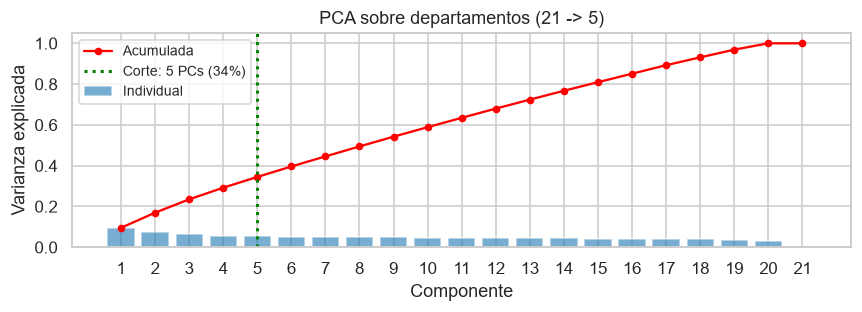

In [ ]:
# Paso 2: PCA agresivo sobre departamentos (21 -> 5 componentes fijos)
N_DEPT_COMPONENTS = 5

dept_cols = [c for c in user_features_t.columns if c.startswith("dept_")]
print(f"Departamentos originales: {len(dept_cols)} features")

# Escalar antes de PCA
scaler_dept = StandardScaler()
dept_scaled = scaler_dept.fit_transform(user_features_t[dept_cols])

# PCA completo para ver varianza
pca_full = PCA(random_state=SEED)
pca_full.fit(dept_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print(f"Varianza explicada con {N_DEPT_COMPONENTS} componentes: {cum_var[N_DEPT_COMPONENTS-1]:.1%}")
print("Varianza individual por componente:")
for i in range(min(8, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.3%} (acum: {cum_var[i]:.1%})")

# PCA final con N componentes
pca_dept = PCA(n_components=N_DEPT_COMPONENTS, random_state=SEED)
dept_pcs = pca_dept.fit_transform(dept_scaled)

dept_pc_cols = [f"dept_pc{i+1}" for i in range(N_DEPT_COMPONENTS)]
dept_pc_df = pd.DataFrame(dept_pcs, index=user_features_t.index, columns=dept_pc_cols)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, len(cum_var)+1), pca_full.explained_variance_ratio_, alpha=0.6, label="Individual")
ax.plot(range(1, len(cum_var)+1), cum_var, "o-", color="red", markersize=4, label="Acumulada")
ax.axvline(N_DEPT_COMPONENTS, ls=":", color="green", lw=2, label=f"Corte: {N_DEPT_COMPONENTS} PCs ({cum_var[N_DEPT_COMPONENTS-1]:.0%})")
ax.set_xlabel("Componente")
ax.set_ylabel("Varianza explicada")
ax.set_title("PCA sobre departamentos (21 -> 5)")
ax.legend(fontsize=9)
ax.set_xticks(range(1, len(cum_var)+1))
plt.tight_layout()
plt.show()

In [13]:
# Paso 3: Eliminar redundancia temporal (share_tarde, la mas comun)
# Las 4 franjas suman 1 -> colinealidad perfecta. Eliminamos una.
drop_temporal = "share_tarde"

# Construir set final de features
behavioral_cols = ["n_orders", "total_items", "mean_days_since_prior", "std_days_since_prior",
                   "mean_basket_size", "unique_products", "reorder_rate"]
temporal_cols = ["share_madrugada", "share_manana", "share_noche", "share_weekend"]

X_pre = user_features_t[behavioral_cols + temporal_cols].join(dept_pc_df)

final_feature_names = list(X_pre.columns)
print(f"\nFeatures finales para clustering: {X_pre.shape[1]}")
print(f"  Conductuales: {len(behavioral_cols)} ({behavioral_cols})")
print(f"  Temporales:   {len(temporal_cols)} (sin {drop_temporal})")
print(f"  Dept PCs:     {N_DEPT_COMPONENTS}")
print(f"  TOTAL:        {X_pre.shape[1]} (reducido desde 33)")


Features finales para clustering: 16
  Conductuales: 7 (['n_orders', 'total_items', 'mean_days_since_prior', 'std_days_since_prior', 'mean_basket_size', 'unique_products', 'reorder_rate'])
  Temporales:   4 (sin share_tarde)
  Dept PCs:     5
  TOTAL:        16 (reducido desde 33)


In [ ]:
# Paso 4: StandardScaler global
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pre.values)

# Persistir transformadores
joblib.dump(scaler, MODELS / "scaler_segmentation.joblib")
joblib.dump(pca_dept, MODELS / "pca_dept_segmentation.joblib")
joblib.dump(scaler_dept, MODELS / "scaler_dept_segmentation.joblib")

print(f"X escalada: {X_scaled.shape}")
print("Transformadores guardados en models/")

X escalada: (162633, 16)
Transformadores guardados en models/


## 6. Eleccion de k — K-Means (k = 2..8)

Barremos k de 2 a 8 y calculamos tres metricas:
- **Inercia (codo):** buscar el codo donde la ganancia marginal cae
- **Silhouette:** cohesion vs separacion (muestra 15k, O(n^2))
- **Davies-Bouldin:** dispersion intra / separacion inter (menor = mejor)

In [15]:
K_RANGE = range(2, 9)
SAMPLE_SIZE = 15_000

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_scaled), size=min(SAMPLE_SIZE, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    km.fit(X_scaled)
    labels_sample = km.labels_[sample_idx]

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels_sample, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_sample, labels_sample))
    print(f"k={k:2d} | inercia={km.inertia_:>12,.0f} | silhouette={silhouettes[-1]:.4f} | DB={db_scores[-1]:.4f}")

print("\nBarrido completado.")
print(f"Mejor silhouette: {max(silhouettes):.4f} en k={list(K_RANGE)[np.argmax(silhouettes)]}")

k= 2 | inercia=   2,194,283 | silhouette=0.1412 | DB=2.1426
k= 3 | inercia=   2,022,467 | silhouette=0.1249 | DB=2.4164
k= 4 | inercia=   1,933,304 | silhouette=0.1056 | DB=2.5071
k= 5 | inercia=   1,847,918 | silhouette=0.1074 | DB=2.2926
k= 6 | inercia=   1,785,628 | silhouette=0.0928 | DB=2.2938
k= 7 | inercia=   1,720,363 | silhouette=0.0817 | DB=2.2155
k= 8 | inercia=   1,671,878 | silhouette=0.0803 | DB=2.1805

Barrido completado.
Mejor silhouette: 0.1412 en k=2


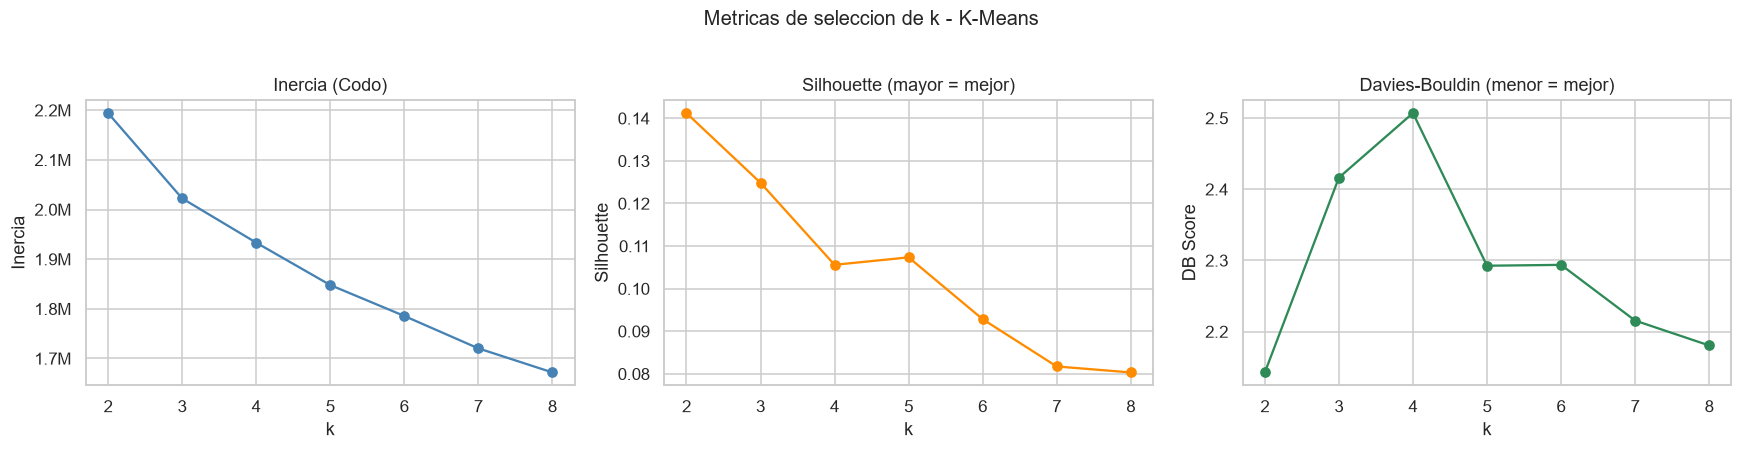

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
k_vals = list(K_RANGE)

axes[0].plot(k_vals, inertias, "o-", color="steelblue")
axes[0].set_title("Inercia (Codo)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(k_vals, silhouettes, "o-", color="darkorange")
axes[1].set_title("Silhouette (mayor = mejor)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(k_vals, db_scores, "o-", color="seagreen")
axes[2].set_title("Davies-Bouldin (menor = mejor)")
axes[2].set_xlabel("k")
axes[2].set_ylabel("DB Score")

for ax in axes:
    ax.set_xticks(k_vals)

plt.suptitle("Metricas de seleccion de k - K-Means", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Decision de k

Elegimos k con el mejor silhouette. Si k=2 gana pero queremos mas granularidad para negocio, podemos forzar k=4 o k=5 mientras el silhouette sea razonable (>0.05).

In [ ]:
# Elegir k: preferimos silhouette pero con al menos 3 clusters para accionabilidad
# Si k=2 tiene el mejor score pero la diferencia con k=4/5 es <0.02, elegimos el mayor
best_idx = int(np.argmax(silhouettes))
K_FINAL = k_vals[best_idx]

# Si k=2 y queremos mas granularidad, subimos a k con mejor silhouette en rango 3-6
if K_FINAL == 2:
    candidates = [(k, s) for k, s in zip(k_vals, silhouettes) if k >= 3]
    if candidates:
        k_alt, sil_alt = max(candidates, key=lambda x: x[1])
        print(f"k=2 tiene silhouette={silhouettes[0]:.4f}")
        print(f"Mejor alternativa con k>=3: k={k_alt}, silhouette={sil_alt:.4f}")
        # Si la diferencia es razonable (<0.03), preferimos mas clusters
        if silhouettes[0] - sil_alt < 0.03:
            K_FINAL = k_alt
            print(f"-> Elegimos k={K_FINAL} (diferencia < 0.03, mayor accionabilidad)")
        else:
            print("-> Mantenemos k=2 (diferencia > 0.03, separacion clara)")

print(f"\nk FINAL: {K_FINAL}")

k=2 tiene silhouette=0.1412
Mejor alternativa con k>=3: k=3, silhouette=0.1249
-> Elegimos k=3 (diferencia < 0.03, mayor accionabilidad)

k FINAL: 3


In [18]:
# K-Means final
km_final = KMeans(n_clusters=K_FINAL, n_init=20, random_state=SEED)
km_final.fit(X_scaled)

user_features["cluster"] = km_final.labels_

print(f"K-Means final con k={K_FINAL}")
print(f"Inercia: {km_final.inertia_:,.0f}")
print()
print("Distribucion:")
sizes = user_features["cluster"].value_counts().sort_index()
for cid, n in sizes.items():
    print(f"  Cluster {cid}: {n:>7,} usuarios ({100*n/len(user_features):.1f}%)")

K-Means final con k=3
Inercia: 2,022,467

Distribucion:
  Cluster 0:  35,555 usuarios (21.9%)
  Cluster 1:  54,255 usuarios (33.4%)
  Cluster 2:  72,823 usuarios (44.8%)


## 7. Validacion con Clustering Jerarquico (Ward)

Muestra de 15k + jerarquico Ward. ARI mide acuerdo entre particiones.

Linkage Ward sobre 15,000 puntos...


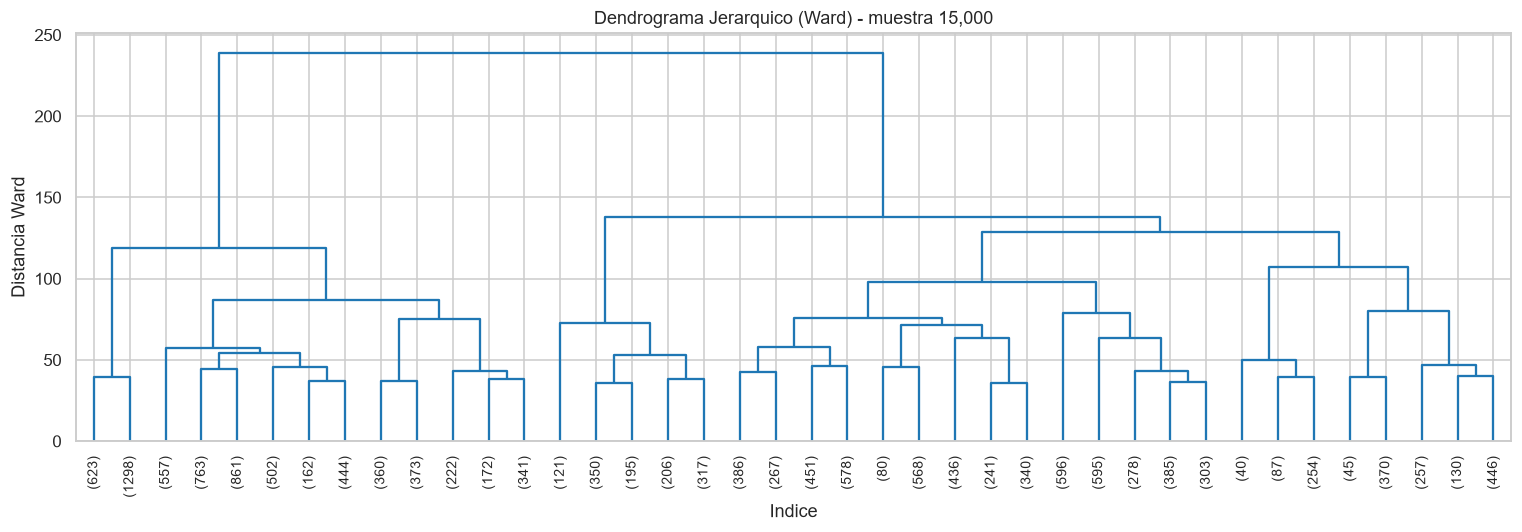

In [19]:
print(f"Linkage Ward sobre {len(X_sample):,} puntos...")
Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90, leaf_font_size=9, ax=ax, color_threshold=0)
ax.set_title(f"Dendrograma Jerarquico (Ward) - muestra {len(X_sample):,}", fontsize=12)
ax.set_xlabel("Indice")
ax.set_ylabel("Distancia Ward")
plt.tight_layout()
plt.show()

In [20]:
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_agg = agg.fit_predict(X_sample)
labels_km_sample = km_final.labels_[sample_idx]

ari = adjusted_rand_score(labels_agg, labels_km_sample)
print(f"ARI (Jerarquico vs K-Means, k={K_FINAL}): {ari:.4f}")
print()
crosstab = pd.crosstab(
    pd.Series(labels_km_sample, name="KMeans"),
    pd.Series(labels_agg, name="Jerarquico"),
)
print("Crosstab:")
print(crosstab)

ARI (Jerarquico vs K-Means, k=3): 0.2579

Crosstab:
Jerarquico     0     1    2
KMeans                     
0           2690   346  257
1            325  4505  229
2           4118  1827  703


## 8. Profiling de Clusters — Personas

Centroides en **espacio original** (sin log, sin PCA) para interpretabilidad.  
Los departamentos se muestran con proporciones reales, no PCs.

In [21]:
profile_cols = [
    "n_orders", "total_items", "mean_days_since_prior", "std_days_since_prior",
    "mean_basket_size", "unique_products", "reorder_rate",
    "share_manana", "share_tarde", "share_noche", "share_madrugada", "share_weekend",
]

profiles = user_features.groupby("cluster")[profile_cols].mean().round(3)
profiles.index.name = "Cluster"

sizes = user_features["cluster"].value_counts().sort_index().rename("n_usuarios")
profiles.insert(0, "n_usuarios", sizes)
profiles.insert(1, "pct_usuarios", (sizes / sizes.sum() * 100).round(1))

print("Perfiles (espacio original):")
display(profiles)

Perfiles (espacio original):


,n_usuarios,pct_usuarios,n_orders,total_items,mean_days_since_prior,std_days_since_prior,mean_basket_size,unique_products,reorder_rate,share_manana,share_tarde,share_noche,share_madrugada,share_weekend
Cluster,,,,,,,,,,,,,,
0,35555,21.9,10.899,43.490,16.311,7.852,4.320,21.298,0.465,0.380,0.452,0.148,0.020,0.299
1,54255,33.4,35.790,394.131,8.725,5.705,11.856,124.226,0.648,0.348,0.464,0.171,0.017,0.352
2,72823,44.8,10.096,110.722,16.928,8.871,11.502,64.643,0.380,0.263,0.511,0.206,0.020,0.382


In [22]:
# Mix de departamentos por cluster
dept_cols_orig = [c for c in user_features.columns if c.startswith("dept_")]
dept_profiles = user_features.groupby("cluster")[dept_cols_orig].mean()

dept_std = dept_profiles.std()
top_depts = dept_std.nlargest(8).index.tolist()

print("Top 8 departamentos mas diferenciales:")
print(dept_profiles[top_depts].round(4))

Top 8 departamentos mas diferenciales:
         dept_beverages  dept_snacks  dept_produce  dept_dairy_eggs  \
cluster                                                               
0                0.1609       0.1201        0.2583           0.1353   
1                0.0847       0.0887        0.3027           0.1722   
2                0.0738       0.0761        0.2773           0.1587   

         dept_frozen  dept_household  dept_dry_goods_pasta  dept_canned_goods  
cluster                                                                        
0             0.0522          0.0465                0.0095             0.0167  
1             0.0654          0.0213                0.0241             0.0298  
2             0.0826          0.0246                0.0330             0.0404  


In [23]:
# Nombres de personas
def auto_nombre(row, all_profiles):
    parts = []
    
    if row["n_orders"] >= all_profiles["n_orders"].quantile(0.80):
        parts.append("Frecuente")
    elif row["n_orders"] <= all_profiles["n_orders"].quantile(0.20):
        parts.append("Ocasional")
    else:
        parts.append("Regular")

    if row["mean_days_since_prior"] <= 8:
        parts.append("semanal")
    elif row["mean_days_since_prior"] <= 14:
        parts.append("bisemanal")
    else:
        parts.append("quincenal+")

    if row["mean_basket_size"] >= all_profiles["mean_basket_size"].quantile(0.75):
        parts.append("carrito grande")
    elif row["mean_basket_size"] <= all_profiles["mean_basket_size"].quantile(0.25):
        parts.append("carrito chico")

    if row["reorder_rate"] >= 0.55:
        parts.append("leal")
    elif row["reorder_rate"] <= 0.35:
        parts.append("explorador")

    if row["share_weekend"] >= 0.45:
        parts.append("finde")

    return " / ".join(parts) if parts else "Medio"

profiles["persona"] = profiles[profile_cols].apply(
    lambda row: auto_nombre(row, profiles), axis=1
)

print("Personas:")
for cid, row in profiles.iterrows():
    print(f"  Cluster {cid} ({row['n_usuarios']:>6,.0f}, {row['pct_usuarios']:>5.1f}%): {row['persona']}")

Personas:
  Cluster 0 (35,555,  21.9%): Regular / quincenal+ / carrito chico
  Cluster 1 (54,255,  33.4%): Frecuente / bisemanal / carrito grande / leal
  Cluster 2 (72,823,  44.8%): Ocasional / quincenal+


## 9. Visualizaciones

Varianza explicada 2D: PC1=23.5%, PC2=12.4%, Total=35.9%


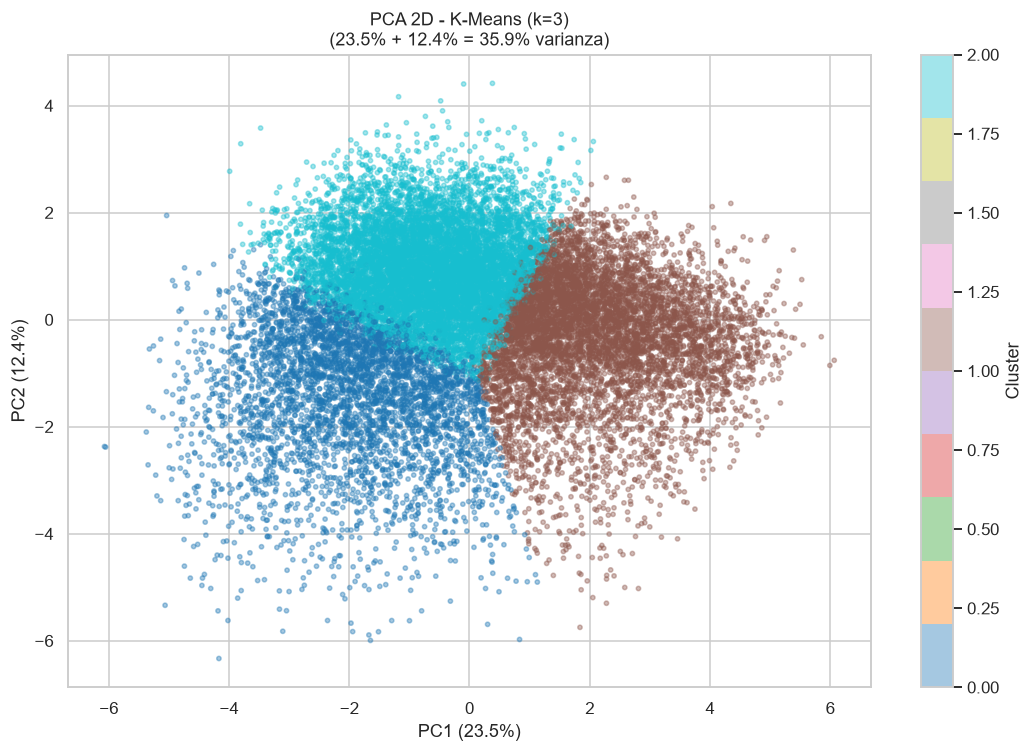

In [24]:
# PCA 2D sobre features finales
pca_viz = PCA(n_components=2, random_state=SEED)
X_pca = pca_viz.fit_transform(X_scaled)

var_exp = pca_viz.explained_variance_ratio_
print(f"Varianza explicada 2D: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}, Total={sum(var_exp):.1%}")

VIZ_SAMPLE = 20_000
viz_idx = rng.choice(len(X_pca), size=min(VIZ_SAMPLE, len(X_pca)), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[viz_idx, 0], X_pca[viz_idx, 1],
    c=km_final.labels_[viz_idx],
    cmap="tab10", alpha=0.4, s=8, rasterized=True,
)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title(f"PCA 2D - K-Means (k={K_FINAL})\n"
             f"({var_exp[0]:.1%} + {var_exp[1]:.1%} = {sum(var_exp):.1%} varianza)", fontsize=12)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
plt.tight_layout()
plt.show()

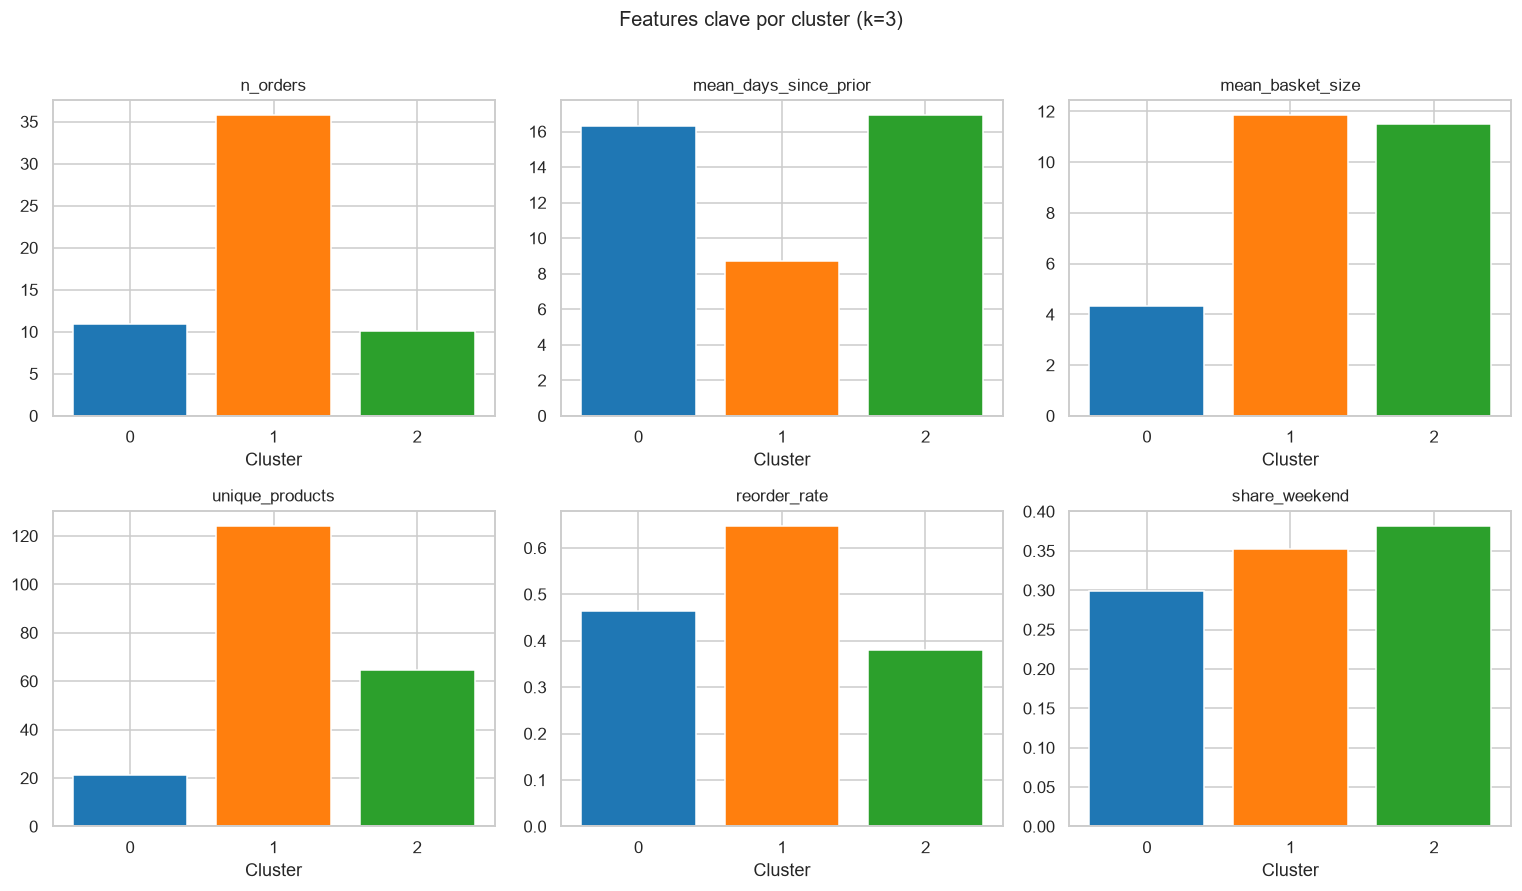

In [25]:
# Barras de features clave
key_features = ["n_orders", "mean_days_since_prior", "mean_basket_size",
                "unique_products", "reorder_rate", "share_weekend"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = sns.color_palette("tab10", K_FINAL)

for i, feat in enumerate(key_features):
    vals = profiles[feat]
    axes[i].bar(vals.index, vals.values, color=palette[:len(vals)])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("Cluster")
    axes[i].set_xticks(vals.index)

plt.suptitle(f"Features clave por cluster (k={K_FINAL})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

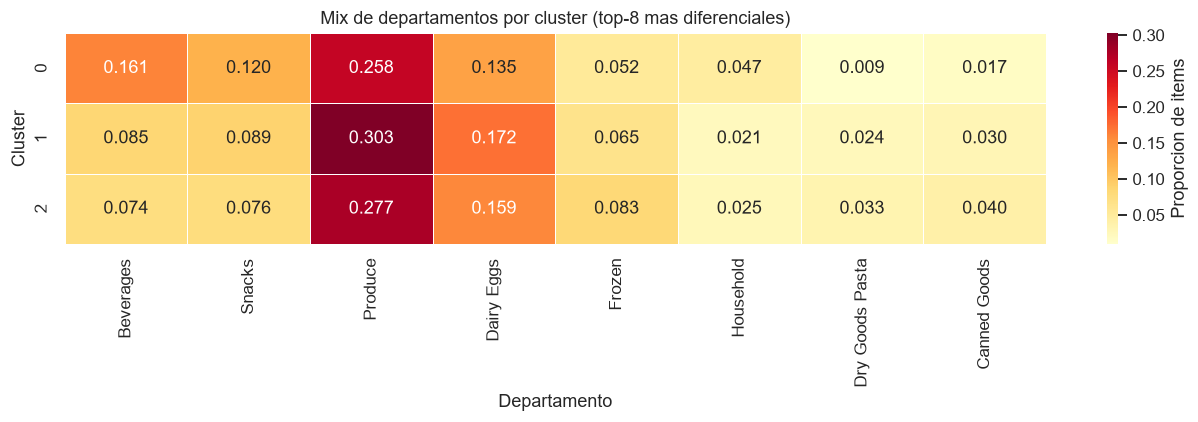

In [26]:
# Heatmap de departamentos
fig, ax = plt.subplots(figsize=(12, max(4, K_FINAL * 0.9)))

dept_heat = dept_profiles[top_depts].copy()
dept_heat.columns = [c.replace("dept_", "").replace("_", " ").title() for c in dept_heat.columns]

sns.heatmap(
    dept_heat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
    linewidths=0.5, cbar_kws={"label": "Proporcion de items"},
)
ax.set_title("Mix de departamentos por cluster (top-8 mas diferenciales)", fontsize=12)
ax.set_ylabel("Cluster")
ax.set_xlabel("Departamento")
plt.tight_layout()
plt.show()

## 10. Persistencia de Resultados

In [ ]:
# user_segments.parquet
keep_cols = ["n_orders", "mean_days_since_prior", "mean_basket_size",
             "unique_products", "reorder_rate", "share_weekend", "cluster"]
user_segments = user_features[keep_cols].copy()
user_segments.index.name = "user_id"
user_segments.to_parquet(DATA_PROC / "user_segments.parquet")

# segment_profiles.csv
profiles.to_csv(DATA_PROC / "segment_profiles.csv")

# kmeans_segmentation.joblib
joblib.dump(km_final, MODELS / "kmeans_segmentation.joblib")

print("Artefactos guardados:")
print(f"  data/processed/user_segments.parquet ({len(user_segments):,} usuarios)")
print("  data/processed/segment_profiles.csv")
print("  models/kmeans_segmentation.joblib")
print("  models/scaler_segmentation.joblib")
print("  models/pca_dept_segmentation.joblib")
print("  models/scaler_dept_segmentation.joblib")

Artefactos guardados:
  data/processed/user_segments.parquet (162,633 usuarios)
  data/processed/segment_profiles.csv
  models/kmeans_segmentation.joblib
  models/scaler_segmentation.joblib
  models/pca_dept_segmentation.joblib
  models/scaler_dept_segmentation.joblib


## 11. Resumen Final

In [29]:
sil_final = silhouettes[k_vals.index(K_FINAL)]
db_final  = db_scores[k_vals.index(K_FINAL)]

print("=" * 60)
print("  RESUMEN - Clustering / Segmentacion de Clientes")
print("=" * 60)
print("  Algoritmo           : K-Means")
print(f"  k elegido           : {K_FINAL}")
print(f"  Usuarios segmentados: {len(user_features):,}")
print("  Features originales : 33")
print(f"  Features finales    : {X_scaled.shape[1]}")
print()
print("  Metricas de calidad:")
print(f"    Silhouette    : {sil_final:.4f}")
print(f"    Davies-Bouldin: {db_final:.4f}")
print(f"    ARI vs Ward   : {ari:.4f}")
print()
print("  Preprocesamiento aplicado:")
print("    - log1p() a features sesgadas")
print(f"    - PCA dept 21 -> {N_DEPT_COMPONENTS} componentes")
print("    - Eliminar share_tarde (redundancia composicional)")
print("    - StandardScaler global")
print()
print("  Segmentos:")
for cid, row in profiles.iterrows():
    print(f"    Cluster {cid}: {row['n_usuarios']:>7,.0f} ({row['pct_usuarios']:>4.1f}%) | {row['persona']}")
print("=" * 60)

  RESUMEN - Clustering / Segmentacion de Clientes
  Algoritmo           : K-Means
  k elegido           : 3
  Usuarios segmentados: 162,633
  Features originales : 33
  Features finales    : 16

  Metricas de calidad:
    Silhouette    : 0.1249
    Davies-Bouldin: 2.4164
    ARI vs Ward   : 0.2579

  Preprocesamiento aplicado:
    - log1p() a features sesgadas
    - PCA dept 21 -> 5 componentes
    - Eliminar share_tarde (redundancia composicional)
    - StandardScaler global

  Segmentos:
    Cluster 0:  35,555 (21.9%) | Regular / quincenal+ / carrito chico
    Cluster 1:  54,255 (33.4%) | Frecuente / bisemanal / carrito grande / leal
    Cluster 2:  72,823 (44.8%) | Ocasional / quincenal+
